<center 
        style="color:MidnightBlue;    
               font-family:Georgia;
               font-size:18pt;
               font-weight:bold">
           WaPOR Based Wheat Yield & Wheat Water Productivity Tool for Ethiopia
</center>

***
## Introduction

The WaPOR Wheat Yield and Water Productivity Estimation Tool for Ethiopia is a Python-based tool developed to help estimate wheat yield and water productivity using satellite-derived information. The tool uses data from the FAO WaPOR (Water Productivity through Open-access of Remotely sensed derived data) platform, particularly Net Primary Production (NPP) and Actual Evapotranspiration and Interception (AETI), to assess how much wheat is produced and how efficiently water is being used across different areas of Ethiopia.

The main idea behind the tool is NPP provides information on crop biomass production, while AETI provides an estimate of the water consumed by the crop. By combining these datasets with appropriate wheat crop parameters, the tool estimates wheat biomass and yield and then calculates water productivity as the amount of wheat produced per unit of water consumed.

This approach is particularly useful for Ethiopia because detailed field-based information on crop yield and water consumption is not always available at the spatial scale needed for irrigation planning and water management. WaPOR provides consistent, spatially distributed information that can help fill this gap and allow wheat performance to be assessed across larger areas using a common methodology. 

This Python based tool can make the analysis easier to reproduce, update, and adapt. The workflow can be applied to different locations and datasets and can be further improved as better local information becomes available. For example, the general wheat crop parameters currently used in the estimation can be replaced with Ethiopia-specific parameters developed by research institutions such as the Ethiopian Institute of Agricultural Research (EIAR). More Field observations and measured yield data can also be used to further calibrate and validate the estimates.

The results from the tool can provide useful information for irrigation planning, agricultural water management, and assessment of crop performance. In particular, the combination of yield and water productivity helps identify areas where wheat production is relatively high, where water is being used more efficiently, and where there may be opportunities to improve irrigation and crop management.

The current tool should be viewed as a practical estimation and decision-support tool rather than a replacement for field measurements. The reliability of the results depends on the quality of the WaPOR data, the crop parameters used, and the assumptions made in the estimation process. Continued calibration and validation using local wheat data and field observations will therefore be important for improving the accuracy and usefulness of the tool for different agro-ecological zones and production systems across Ethiopia.



## Load necessary Python modules

In [1]:
# Load custom utility tool 
from etwapor import download, metadata, productivity, util

#import random
#import requests
#from tqdm import tqdm
# module for plotting
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd
# For reading Shapefiles
import geopandas as gpd

# Load xarray for handling N-dimensional data
#import xarray as xr
import seaborn as sns
# Load rioxarry, a package build on xarray and rasterio to 
# facilitate raster analysis
#from rasterio.enums import Resampling 
#import rioxarray as rxr 
#from shapely.geometry import Point
pd.set_option('display.float_format', '{:.2f}'.format)

ModuleNotFoundError: No module named 'etwapor'

## Load irrigation scheme Shapefiles

In [13]:
# Set path to the geographid data of irrigation scheme
irrigation_scheme_pnt=r"Data/Irrigated_Wheat_2026_PNT.shp"
irrigation_scheme_poly=r"Data/Irrigated_Wheat_2026.shp"

# Read Shapefiles
gdf_pnt = gpd.read_file(irrigation_scheme_pnt) 
gdf_poly = gpd.read_file(irrigation_scheme_poly) 
# Select scheme to zoom-in to
scheme = gdf_poly[gdf_poly['Name'] == 'Amibara']
centroid = scheme.geometry.union_all().centroid

NameError: name 'gpd' is not defined

### Loading and Visualizing Input Shapefiles
Load Shapefiles as a GeoPandas GeoDataFrame. The loaded data can be quickly inspected and visualized using the GeoPandas explore() method, which provides an interactive map for checking the location, shape, and distribution of the irrigation schemes or farm plots. Where multiple schemes are included in a single input dataset, one selected scheme can be used as the initial zoom-in location to make it easier to inspect the input features in detail. This visual check provides an additional opportunity to identify potential spatial or geometry issues before the data are passed to the WaPOR-based water productivity estimation workflow.

In [3]:
# Plot scheme locations
g = gdf_poly.explore(tiles='Esri.WorldImagery',
                location=[centroid.y,centroid.x],
                zoom_start=18,  
                style_kwds={
                    "color": "gray",
                    "weight": 3,
                }
                
               )
gdf_pnt.explore(m=g,name='Ethiopia',
            color="none",          
            style_kwds={                        
                    "color": "red",
                    "fillColor": "blue",
                    "opacity": 0.8,
                    "fillOpacity": 0.6,
                    "radius": 5
    },
           )

### Input Data Validation
Before the input data are passed to the estimation functions, a basic validation process should be carried out to ensure that all required fields are present and contain valid information. The ID, SOS (Start of Season), EOS (End of Season), geometry and Location (for point features only) fields are mandatory and must be properly checked before the analysis begins. The ID field should contain integer values and should uniquely identify each feature or irrigation scheme. The SOS and EOS fields represent the start and end of the crop growing season and can be provided either as date strings or as datetime64[ms] values; the dates should be valid and the EOS should occur after the SOS. The geometry field must contain valid spatial geometries, such as points or polygons, with an appropriate coordinate reference system. The Location field must be included for the point features to differentiate the samples bloging to individual plots. Records with missing, invalid, or incorrectly formatted mandatory fields should be flagged and corrected before being processed by the tool. These checks help prevent data-format and spatial errors from propagating into the yield and water productivity calculations and ensure that the results are based on consistent and reliable input data.

In [4]:
# Check the first 5 records and fields for point features
gdf_poly.head()

,Shape_Leng,Shape_Area,Crop,SOS,EOS,Scheme_ID,Crop_ID,Area_ha,Name,ID,geometry
0,0.01,0.00,Wheat,2025-11-22,2026-02-20,AF001,CER01,12.62,Amibara,1,"POLYGON Z ((40.16921 9.34453 0, 40.17063 9.346..."
1,0.03,0.00,Wheat,2025-11-20,2026-03-16,AF002,CER01,50.99,Dubti,2,"POLYGON Z ((41.11883 11.73765 0, 41.11427 11.7..."
2,0.03,0.00,Wheat,2025-11-20,2026-03-16,AF002,CER01,57.01,Dubti,3,"POLYGON Z ((41.11409 11.73839 0, 41.10893 11.7..."
3,0.03,0.00,Wheat,2025-11-20,2026-03-16,AF002,CER01,46.64,Dubti,4,"POLYGON Z ((41.10875 11.73912 0, 41.10431 11.7..."
4,0.01,0.00,Wheat,2024-12-02,2025-04-02,OR001,CER01,7.37,Dodota,5,"POLYGON Z ((39.38397 8.2944 0, 39.38497 8.2937..."


In [5]:
# check datatypes all the fields
gdf_poly.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Shape_Leng  6 non-null      float64       
 1   Shape_Area  6 non-null      float64       
 2   Crop        6 non-null      object        
 3   SOS         6 non-null      datetime64[ms]
 4   EOS         6 non-null      datetime64[ms]
 5   Scheme_ID   6 non-null      object        
 6   Crop_ID     6 non-null      object        
 7   Area_ha     6 non-null      float64       
 8   Name        6 non-null      object        
 9   ID          6 non-null      int64         
 10  geometry    6 non-null      geometry      
dtypes: datetime64[ms](2), float64(3), geometry(1), int64(1), object(4)
memory usage: 660.0+ bytes


In [6]:
# Check the first 5 records and fields for polygon features
gdf_pnt.head()

,ID,Name,Location,SOS,EOS,Crop,Scheme_ID,Crop_ID,geometry
0,1,Amibara,1,2025-11-22,2026-02-20,Wheat,AF001,CER01,POINT (40.1723 9.34233)
1,2,Amibara,1,2025-11-22,2026-02-20,Wheat,AF001,CER01,POINT (40.17233 9.34323)
2,3,Amibara,1,2025-11-22,2026-02-20,Wheat,AF001,CER01,POINT (40.17135 9.34326)
3,4,Amibara,1,2025-11-22,2026-02-20,Wheat,AF001,CER01,POINT (40.17138 9.34428)
4,5,Amibara,1,2025-11-22,2026-02-20,Wheat,AF001,CER01,POINT (40.17049 9.34426)


In [7]:
# check datatypes all the fields
gdf_pnt.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   ID         57 non-null     int64         
 1   Name       57 non-null     object        
 2   Location   57 non-null     int32         
 3   SOS        57 non-null     datetime64[ms]
 4   EOS        57 non-null     datetime64[ms]
 5   Crop       57 non-null     object        
 6   Scheme_ID  57 non-null     object        
 7   Crop_ID    57 non-null     object        
 8   geometry   57 non-null     geometry      
dtypes: datetime64[ms](2), geometry(1), int32(1), int64(1), object(4)
memory usage: 3.9+ KB


In [8]:
gdf_poly = util.validate_input(gdf_poly)

-> Data validation is successful!


In [9]:
gdf_pnt = util.validate_input(gdf_pnt)

-> Data validation is successful!


### Wheat Yield and Water Productivity Estimation Approach
Crop water productivity (CWP) and yield (Y) - Crop water productivity is the measure of crop water use efficiency, which is expressed in crop yield per unit of water use (kg/m$^3$). Crop yield is the amount of crop produced per unit area (kg/ha), which is the measure of how land is efficiently used to produce food.


$$TB = AOT * f_c * \frac{NPP * 22.222}{1 - mc}$$

$$Y = TB * hi$$

$$CWP = \frac{Y}{SWC}$$


&emsp;&emsp;&emsp;where,

&emsp;&emsp;&emsp;&emsp;&emsp;$TB$ = Total biomass in kg/ha,<br>
&emsp;&emsp;&emsp;&emsp;&emsp;$AOT$ = Ratio of above ground over total biomass ,<br>
&emsp;&emsp;&emsp;&emsp;&emsp;$f_c$ = Light use efficiency correction factor,<br>
&emsp;&emsp;&emsp;&emsp;&emsp;$NPP$ = Seasonal net primary production in gC/m$^2$/season, and<br>
&emsp;&emsp;&emsp;&emsp;&emsp;$mc$ = Moisture content in the fresh biomass, <br>
&emsp;&emsp;&emsp;&emsp;&emsp;$hi$ = Harvest index, <br>
&emsp;&emsp;&emsp;&emsp;&emsp;$Y$ = Yield in kg/ha, <br>
&emsp;&emsp;&emsp;&emsp;&emsp;$CWP$ = Crop water productivity in kg/m$^3$, <br>
&emsp;&emsp;&emsp;&emsp;&emsp;$SWC$ = Seasonal water consumption in m$^3$ <br>


The estimation approach used by the tool follows a simple sequence that links satellite-derived crop productivity with biomass, yield, and water use. First, seasonal WaPOR NPP is converted into total crop biomass (TB) using the above-ground biomass ratio (AOT), the light-use efficiency correction factor (fc), and the moisture content of fresh biomass (mc). The estimated total biomass is then converted into harvestable wheat yield (Y) using the harvest index (hi), which represents the proportion of total biomass that is ultimately harvested as grain. Finally, crop water productivity (CWP) is calculated by dividing the estimated wheat yield by seasonal water consumption (SWC), expressed in cubic metres. In this way, the tool provides two complementary measures of crop performance: yield indicates how much wheat is produced per unit of land, while water productivity indicates how efficiently the consumed water is converted into wheat production. The approach therefore allows wheat production and water-use efficiency to be assessed together, which is particularly useful for evaluating irrigation performance and identifying opportunities to improve agricultural water productivity.

#### Crop Parameter Assumptions for Biomass and Yield Estimation
The wheat crop parameters used in this assessment to estimate biomass and yield are based on general reference values from the FAO database. These values provide a useful starting point for the analysis, particularly where locally measured crop parameters are not readily available. However, they may not fully reflect the conditions under which wheat is grown in different parts of Ethiopia.

Crop growth and yield can vary depending on the agro-ecological zone, climate, soil conditions, wheat variety, and farm management practices. For this reason, the FAO-based parameters should be viewed as default values that can be improved as more locally relevant information becomes available.

The Ethiopian Institute of Agricultural Research (EIAR) has relevant crop information and parameters that could be used to improve the current estimates. Where appropriate, these locally developed parameters can replace the general FAO values and be adapted to the different agro-ecological zones and wheat production systems across Ethiopia.

For future improvements and further calibration of the tool under Ethiopian conditions, it will be important to incorporate EIAR data, field observations, and other locally validated information. Using these sources will help refine the crop parameters and estimation methods to better reflect local agro-ecological and production conditions. This, in turn, will improve the accuracy, reliability, and credibility of the results, while making the tool more relevant and adaptable for future applications, updates, and decision-making.

## Compute yied and water productivity
### Multiple farms/plots boundaries provided

In [10]:

gdf_poly_result = productivity.estimate_wheat_wp( 
    gdf_poly, 
    scheme_code=None )

Processing features:   0%|                                                              | 0/6 [00:00<?, ?featu…

In [11]:
gdf_poly

,Shape_Leng,Shape_Area,Crop,SOS,EOS,Scheme_ID,Crop_ID,Area_ha,Name,ID,geometry,NPP,EYield_tpha,AETI_mm,WP_kgpm3,LGP
0,0.01,0.00,Wheat,2025-11-22,2026-02-20,AF001,CER01,12.62,Amibara,1,"POLYGON Z ((40.16921 9.34453 0, 40.17063 9.346...",184.95,1.78,297.32,0.60,90.00
1,0.03,0.00,Wheat,2025-11-20,2026-03-16,AF002,CER01,50.99,Dubti,2,"POLYGON Z ((41.11883 11.73765 0, 41.11427 11.7...",168.70,1.62,319.43,0.51,116.00
2,0.03,0.00,Wheat,2025-11-20,2026-03-16,AF002,CER01,57.01,Dubti,3,"POLYGON Z ((41.11409 11.73839 0, 41.10893 11.7...",138.29,1.33,291.45,0.46,116.00
3,0.03,0.00,Wheat,2025-11-20,2026-03-16,AF002,CER01,46.64,Dubti,4,"POLYGON Z ((41.10875 11.73912 0, 41.10431 11.7...",65.24,0.63,193.81,0.32,116.00
4,0.01,0.00,Wheat,2024-12-02,2025-04-02,OR001,CER01,7.37,Dodota,5,"POLYGON Z ((39.38397 8.2944 0, 39.38497 8.2937...",478.22,4.59,369.28,1.24,121.00
5,0.00,0.00,Wheat,2025-12-07,2026-03-13,OR002,CER01,4.33,Godino,6,"POLYGON Z ((39.02231 8.84772 0, 39.02236 8.847...",319.52,3.07,219.53,1.40,96.00


##### Save result

In [12]:
gdf_poly_result.drop(columns=['geometry']).to_csv('Irrigated_Wheat_WP_BND_2026.csv', index=False)

### Multiple farms/plots point samples provided

In [13]:
gdf_pnt_result = productivity.estimate_wheat_wp( 
    gdf_pnt, 
    scheme_code=None )

Processing features:   0%|                                                             | 0/57 [00:00<?, ?featu…

In [14]:
gdf_pnt_result.head(10)

,ID,Name,Location,SOS,EOS,Crop,Scheme_ID,Crop_ID,geometry,NPP,EYield_tpha,AETI_mm,WP_kgpm3,LGP
0,1,Amibara,1,2025-11-22,2026-02-20,Wheat,AF001,CER01,POINT (40.1723 9.34233),233.34,2.24,346.70,0.65,90.00
1,2,Amibara,1,2025-11-22,2026-02-20,Wheat,AF001,CER01,POINT (40.17233 9.34323),215.32,2.07,325.60,0.63,90.00
2,3,Amibara,1,2025-11-22,2026-02-20,Wheat,AF001,CER01,POINT (40.17135 9.34326),206.91,1.99,319.00,0.62,90.00
3,4,Amibara,1,2025-11-22,2026-02-20,Wheat,AF001,CER01,POINT (40.17138 9.34428),196.37,1.89,311.10,0.61,90.00
4,5,Amibara,1,2025-11-22,2026-02-20,Wheat,AF001,CER01,POINT (40.17049 9.34426),185.43,1.78,297.60,0.60,90.00
5,6,Dubti,2,2025-11-20,2026-03-16,Wheat,AF002,CER01,POINT (41.11754 11.73883),293.53,2.82,455.20,0.62,116.00
6,7,Dubti,2,2025-11-20,2026-03-16,Wheat,AF002,CER01,POINT (41.11673 11.73978),291.49,2.80,444.50,0.63,116.00
7,8,Dubti,2,2025-11-20,2026-03-16,Wheat,AF002,CER01,POINT (41.11579 11.7388),286.75,2.75,435.90,0.63,116.00
8,9,Dubti,2,2025-11-20,2026-03-16,Wheat,AF002,CER01,POINT (41.11771 11.7417),226.50,2.17,344.10,0.63,116.00
9,10,Dubti,2,2025-11-20,2026-03-16,Wheat,AF002,CER01,POINT (41.11652 11.74172),215.36,2.07,329.90,0.63,116.00


##### Save result

In [15]:
gdf_pnt_result.drop(columns=['geometry']).to_csv('Irrigated_Wheat_WP_PNT_2026.csv', index=False)

#### Aggregate the result for the points to farms/farm plots

In [16]:
group_cols = ['Name','Location','SOS', 'EOS', 'LGP', 'Scheme_ID']
df_agg = (
    gdf_pnt_result.groupby(group_cols, as_index=False)
      .agg({'NPP': 'median',
            'AETI_mm': 'median',
            'EYield_tpha': 'median',
            'WP_kgpm3': 'median'
           })   
)

In [17]:
df_agg

,Name,Location,SOS,EOS,LGP,Scheme_ID,NPP,AETI_mm,EYield_tpha,WP_kgpm3
0,Amibara,1,2025-11-22,2026-02-20,90.00,AF001,206.91,319.00,1.99,0.62
1,Dodota,4,2025-12-11,2026-04-01,111.00,OR001,556.48,378.40,5.34,1.40
2,Dodota,6,2024-12-21,2025-04-02,102.00,OR001,467.68,358.85,4.49,1.24
3,Dubti,2,2025-11-20,2026-03-16,116.00,AF002,197.57,329.90,1.90,0.59
4,Dubti,3,2025-11-20,2026-03-16,116.00,AF002,146.32,322.50,1.40,0.36
5,Godino,5,2025-12-07,2026-03-13,96.00,OR002,425.89,280.20,4.09,1.46


#### Plot results

In [18]:
# Make sure dates are datetime
df_agg['SOS'] = pd.to_datetime(df_agg['SOS'])
df_agg['EOS'] = pd.to_datetime(df_agg['EOS'])

# Calculate season length
df_agg['Season_Length_days'] = (df_agg['EOS'] - df_agg['SOS']).dt.days

# Create a label for plotting
df_agg['Label'] = df_agg['Name']

# Set plotting style
sns.set_theme(style="whitegrid", font_scale=1.0)

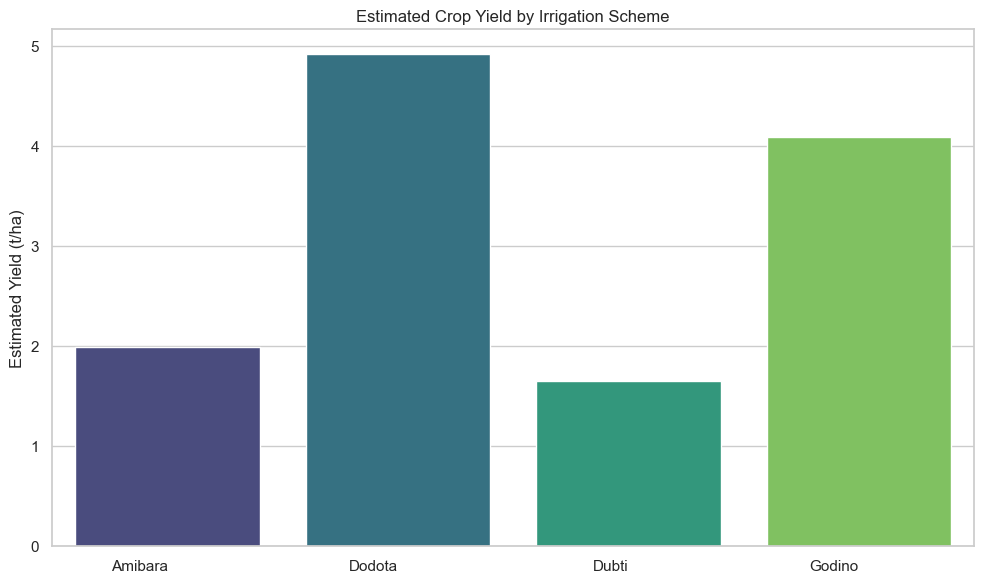

In [21]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_agg,
    x='Label',
    y='EYield_tpha',
    hue='Scheme_ID',
    palette='viridis',
    legend=False,
    errorbar=None
)

plt.ylabel('Estimated Yield (t/ha)')
plt.xlabel('')
plt.title('Estimated Crop Yield by Irrigation Scheme')
plt.xticks(rotation=0, ha='right')

plt.tight_layout()
plt.show()

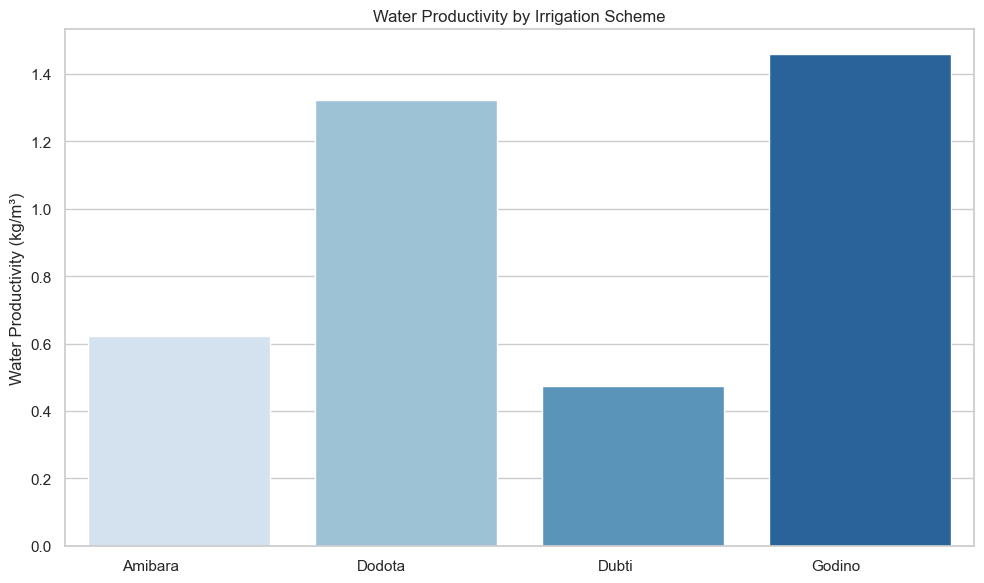

In [22]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_agg,
    x='Label',
    y='WP_kgpm3',
    hue='Scheme_ID',
    palette='Blues',
    legend=False,
    errorbar=None
)

plt.ylabel('Water Productivity (kg/m³)')
plt.xlabel('')
plt.title('Water Productivity by Irrigation Scheme')
plt.xticks(rotation=0, ha='right')

plt.tight_layout()
plt.show()